# **Kaggle Challenge 3: Đề tài dự đoán thể loại nhạc.**
# **PHẦN 4: XÂY DỰNG MÔ HÌNH MÁY HỌC**

## 1. Định nghĩa vấn đề
+ **Mô tả**:
   - Dữ liệu đầu vào gồm 3 file:
      * train_processed.pkl: Dữ liệu từ tập train đã được xử lý ở phần 3.
      * test_processed.pkl: Dữ liệu từ tập  test đã được xử lý ở phần 3.
	  * train_y_processed.pkl: Dữ liệu chứa biến mục tiêu đã được xử lý ở phần 3.

+ **Mục tiêu**:
   - Chọn các tham số thực nghiệm.
   - Chọn các mô hình máy  học và thực hiện huấn luyện mô hình.
   - Đánh giá, cải tiến mô hình máy học. 


## 2. Chuẩn bị vấn đề

### 2.1. Import các thư viện

In [104]:
# Load libraries
from IPython import display
import numpy as np
import pickle

import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

# model selection
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, KFold, train_test_split

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import sklearn

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight
import joblib

# metrics
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

# Hiển thị tối đa 200 cột
pd.set_option('display.max_columns', 200)

### 2.2. Đọc dataset train và test từ dataset đã xử lý trong phần dọn dẹp dữ liệu
Đọc các file .pkl trong thư mục /clean/data

In [105]:
train_data = pd.DataFrame(pd.read_pickle("../preprocessing/data/train_processed.pkl"))
test_data = pd.DataFrame(pd.read_pickle("../preprocessing/data/test_processed.pkl"))
train_y_data = pd.DataFrame(pd.read_pickle("../preprocessing/data/train_y.pkl")).squeeze()

### 2.3. Kiểm tra dữ liệu dataset train và test

In [106]:
train_data.head()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

,Popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,key_2.0,key_3.0,key_4.0,key_5.0,key_6.0,key_6.5,key_7.0,key_8.0,key_9.0,key_10.0,key_11.0,mode_1,time_signature_3,time_signature_4,time_signature_5,CategoryTrack_1,CategoryTrack_2,CategoryTrack_3,CategoryTrack_4,CategoryTrack_5,CategoryArtist_1,CategoryArtist_2,CategoryArtist_3,CategoryArtist_4,CategoryArtist_5,CategoryArtist_6,CategoryArtist_7,CategoryArtist_8,CategoryArtist_9
0,-0.436403,0.334,0.536,0.086697,0.0381,0.378000,0.003475,0.106,0.235,152.429,-0.045761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.306175,0.725,0.747,0.376282,0.0876,0.027200,0.046800,0.104,0.380,132.921,-0.201026,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,-0.029802,0.584,0.804,0.226773,0.0619,0.000968,0.635000,0.284,0.635,159.953,-0.617447,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,-1.888552,0.515,0.308,-1.264658,0.0312,0.907000,0.021300,0.300,0.501,172.472,0.842539,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0.202542,0.565,0.777,0.507956,0.2490,0.183000,0.003475,0.211,0.619,88.311,0.464365,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [107]:
test_data.head()

,Popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,key_2.0,key_3.0,key_4.0,key_5.0,key_6.0,key_6.5,key_7.0,key_8.0,key_9.0,key_10.0,key_11.0,mode_1,time_signature_3,time_signature_4,time_signature_5,CategoryTrack_1,CategoryTrack_2,CategoryTrack_3,CategoryTrack_4,CategoryTrack_5,CategoryArtist_1,CategoryArtist_2,CategoryArtist_3,CategoryArtist_4,CategoryArtist_5,CategoryArtist_6,CategoryArtist_7,CategoryArtist_8,CategoryArtist_9
0,-0.029802,0.691,0.670,-0.018397,0.0941,0.075700,0.035200,0.1970,0.635,89.965,-0.103694,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,-1.772380,0.461,0.777,-0.103084,0.0306,0.388000,0.923000,0.2910,0.525,163.043,0.726949,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2.061293,0.656,0.291,-0.687739,0.0293,0.872000,0.002445,0.1140,0.298,103.971,0.253649,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0.434886,0.480,0.826,0.664241,0.0397,0.000797,0.000001,0.1250,0.687,96.000,0.144308,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,-1.249606,0.734,0.729,0.153053,0.2830,0.147000,0.004930,0.0672,0.805,76.030,-1.345897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [108]:
train_y_data.head()

0     9
1     6
2    10
3     2
4     5
Name: Class, dtype: int64

## 3. Thiết lập các tham số thực nghiệm

In [109]:
params = {}
params["random_state"] = 42
params["k-fold"] = 5

## 4. Chọn các mô hình để huấn luyện

In [ ]:
# Tính class weights từ train_y_data
classes = np.unique(train_y_data)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_y_data)
class_weights_dict = dict(zip(classes, weights))
sample_weights = train_y_data.map(class_weights_dict)  # dùng cho boosting nếu cần

models = {}

# 1. Logistic Regression
models["LogisticRegression"] = LogisticRegression(
    max_iter=10000,
    C=1.0,
    solver="lbfgs",
    class_weight="balanced"
)

# 2. Random Forest
models["RandomForest"] = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    class_weight="balanced",
    random_state=params["random_state"]
)

# 3. Gradient Boosting (sklearn)
models["GradientBoosting"] = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3
)

# 4. XGBoost
models["XGBoost"] = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=params["random_state"]
)

# 5. LightGBM
models["LightGBM"] = LGBMClassifier(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multiclass",
    random_state=params["random_state"]
)

# 6. CatBoost 
models["CatBoost"] = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    verbose=False,
    allow_writing_files=False
)

# 7. SVM
models["SVM"] = SVC(
    C=5000,
    gamma="scale",
    kernel="rbf",
    probability=True,
    class_weight="balanced"
)

# 8. KNN
models["KNN"] = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski"
)


## 5. Thực hiện chia dữ liệu thành train và validation
Dữ liệu train có ~14000 dòng, có thể chia dữ liệu tập train thành 2 tập train và validation với tỷ lệ chia là 80/20 để giúp cho việc huấn luyện nhanh hơn. Dùng stratify để giữ tỷ lệ phân bố lớp.

In [111]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data, train_y_data, test_size=0.2, stratify=train_y_data, random_state=params["random_state"]
)

## 6. Thực hiện huấn luyện và đánh giá mô hình

In [112]:
results = {name: {'accuracy': [], 'f1': [], 'roc_auc': []} for name in models.keys()}

for name, model in models.items():
    # Train trên tập train
    model.fit(X_train, y_train)

    # Dự đoán trên tập validation
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    # Tính các metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    roc_auc = roc_auc_score(
        y_val,
        y_prob,
        multi_class="ovr",
        average="macro"
    )
 
    # Lưu kết quả
    results[name]['accuracy'].append(acc)
    results[name]['f1'].append(f1)
    results[name]['roc_auc'].append(roc_auc)

# Hiển thị kết quả
print("--------------------------")
for name in models.keys():
    acc_mean = sum(results[name]['accuracy']) / len(results[name]['accuracy'])
    f1_mean = sum(results[name]['f1']) / len(results[name]['f1'])
    roc_auc_mean = sum(results[name]['roc_auc']) / len(results[name]['roc_auc'])
    print(f"{name} Results:")
    print(f"  Accuracy: {acc_mean:.4f}")
    print(f"  F1 Score: {f1_mean:.4f}")
    print(f"  ROC AUC:  {roc_auc_mean:.4f}")
    print("-" * 30)

KeyboardInterrupt: 

**Nhận xét**: Các mô hình tốt nhất khi xét trên tính chất F1 là GradientBoosting, XGBoost, LightGBM, CatBoost

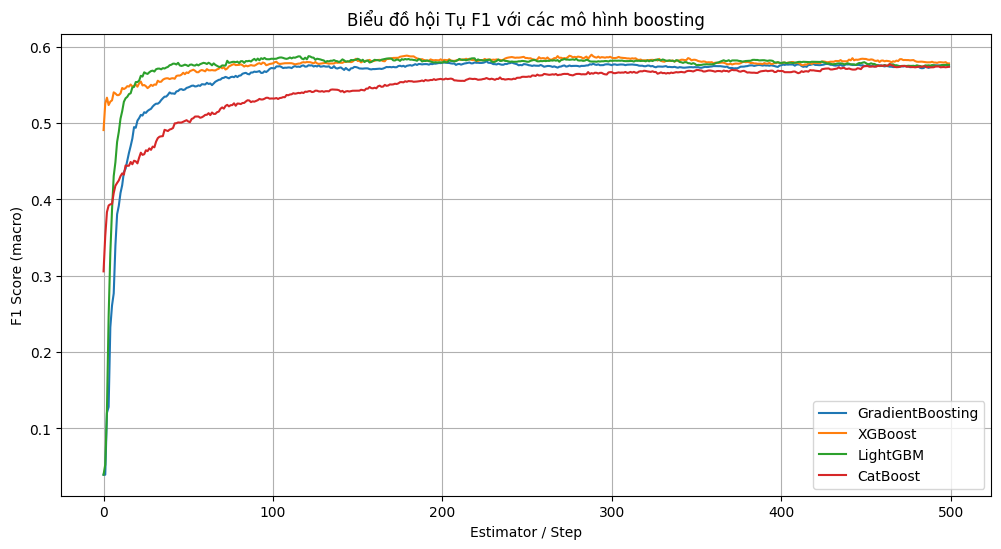

In [ ]:
f1_scores_plot = {}

# --- GradientBoosting (sklearn) ---
if "GradientBoosting" in models:
    gb_model = models["GradientBoosting"]
    val_f1_gb = [f1_score(y_val, y_pred_stage, average="macro") 
                  for y_pred_stage in gb_model.staged_predict(X_val)]
    f1_scores_plot["GradientBoosting"] = val_f1_gb

# --- XGBoost ---
if "XGBoost" in models:
    xgb_model = models["XGBoost"]
    val_f1_xgb = [f1_score(y_val, xgb_model.predict(X_val, iteration_range=(0, i)), average="macro")
                  for i in range(1, xgb_model.n_estimators + 1)]
    f1_scores_plot["XGBoost"] = val_f1_xgb

# --- LightGBM ---
if "LightGBM" in models:
    lgb_model = models["LightGBM"]
    val_f1_lgb = [f1_score(y_val, lgb_model.predict(X_val, num_iteration=i), average="macro")
                  for i in range(1, lgb_model.n_estimators + 1)]
    f1_scores_plot["LightGBM"] = val_f1_lgb

# --- CatBoost ---
if "CatBoost" in models:
    cat_model = models["CatBoost"]
    val_f1_cat = [f1_score(y_val, cat_model.predict(X_val, ntree_end=i), average="macro")
                  for i in range(1, cat_model.get_param("iterations")+1)]
    f1_scores_plot["CatBoost"] = val_f1_cat


# --- Vẽ biểu đồ hội tụ ---
plt.figure(figsize=(12,6))
for name, scores in f1_scores_plot.items():
    plt.plot(scores, label=name)
plt.xlabel("Estimator / Step")
plt.ylabel("F1 Score (macro)")
plt.title("Biểu đồ hội Tụ F1 với các mô hình boosting")
plt.legend()
plt.grid(True)
plt.show()

**Nhận xét**: Hầu hết các mô hình trên biểu đồ hội tụ đến khoảng 0.56-0.57, LightGBM và XGBoost có tốc độ hội tụ nhanh nhất.

## 7. Dùng Stacking Model để huấn luyện
Stack các mô hình GradientBoosting, XGBoost, LightGBM và CatBoost.

In [ ]:
selected_names = ["GradientBoosting", "XGBoost", "LightGBM", "CatBoost"]
estimators = [(name, models[name]) for name in selected_names]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1,
    passthrough=False   
)

In [117]:
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_val)

f1_stack = f1_score(y_val, y_pred_stack, average="macro")
print("F1 Score Stacking:", f1_stack)


F1 Score Stacking: 0.6055811256628079


**Nhận xét:** Dùng Stacking Model góp phần tăng điểm F1 (tăng từ 0.57 lên 0.60).

## 8. Lưu mô hình huấn luyện

In [118]:
best_models = [models["GradientBoosting"], models["XGBoost"], models["CatBoost"],
               models["LightGBM"]]

for i, v in enumerate(best_models):
    joblib.dump(v, f"saved_model{i}.pkl")
    
joblib.dump(stacking_model, "saved_model_stacking.pkl")

['saved_model_stacking.pkl']

## 9. Lưu file backup
Lưu thành file ipynb trong thư mục backup.

In [ ]:
from datetime import datetime
import os

# Lấy ngày và giờ
timestamp = datetime.now().strftime("%d-%m_%H-%M")

# Thêm ngày giờ vào notebook
notebook_name = f"model_{timestamp}"

# Chọn thư mục lưu vào
save_dir = "..\\exps\\models"
# Chọn file hiện hành
curr_file = "model.ipynb"

# Xuất ra file ipynb.
os.system(f"copy {curr_file} {save_dir}\\{notebook_name}.ipynb")

0

# **Kết thúc**